<a href="https://colab.research.google.com/github/Kohei-200/math/blob/main/ASP/02TWM_vectorized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Demo2 on Two Way Mismatch and further

[TWM with Matrix Representation](https://github.com/Kohei-200/math/blob/main/ASP/YIN_TWMwithMatrix.ipynb) turned out to be visually comprehensible.

---

**However**, while fully vectorized numpy broadcasting with its high space complexity makes very small input sizes execute faster than using Python loops, large acoustic data with thougsands of frequencies makes the 3D grid massive, eating much computer memory which **cancels out** the speed.

---

Additionally, this implementation use Linear Amplitude, and scale magnitude with a_r/ Amax directly, so input magnitudes dB are to be converted.

In [42]:
# audio sample MTG sms-tools
!git clone https://github.com/MTG/sms-tools-materials.git

fatal: destination path 'sms-tools-materials' already exists and is not an empty directory.


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import soundfile as sf
import scipy
import scipy.fft as fft
from scipy import signal

#### Two-pass search on candidates

pass 1 search the entire range using 1-semitone steps

pass 2 take the note from pass 1 to focus on, to make it resolute.

In [44]:
import numpy as np

def estimate_f0_twm_errors(f_k, A_k, candidates, maxnpeaks = 10):
    """Estimates fundamental frequency (f0) using the Two-Way Mismatch algorithm."""

    p=0.5
    q=1.4
    r=0.5
    rho=0.33

    f_k = np.atleast_1d(f_k)
    A_k = np.atleast_1d(A_k)
    candidates = np.atleast_1d(candidates)

    Amax = np.max(A_k)
    K = len(f_k)
    N = min(maxnpeaks, K)

    nH = np.arange(1, N + 1)

    # (Candidates x Harmonics x Peaks)
    f_r = candidates[:, np.newaxis] * nH
    all_distances_pm = np.abs(f_r[:, :, np.newaxis] - f_k[np.newaxis, np.newaxis, :])

    # P -> M Error
    delta_fr = np.min(all_distances_pm, axis=2)
    closest_indices_pm = np.argmin(all_distances_pm, axis=2)
    a_r = A_k[closest_indices_pm]

    error_matrix_pm = delta_fr * (f_r**-p) + (a_r / Amax) * (q * delta_fr * (f_r**-p) - r)
    err_pm = np.sum(error_matrix_pm, axis=1)

    # M -> P Error
    n_hk = np.round(f_k[np.newaxis, :] / candidates[:, np.newaxis])
    n_hk = np.maximum(1, n_hk)

    f_pred = n_hk * candidates[:, np.newaxis]

    delta_fk = np.abs(f_k[np.newaxis, :] - f_pred)
    # NumPy broadcasts f_k and A_k across the 2D matrix
    error_matrix_mp = delta_fk * (f_k**-p) + (A_k / Amax) * (q * delta_fk * (f_k**-p) - r)
    err_mp = np.sum(error_matrix_mp, axis=1)


    Err_total = (err_pm / N) + rho * (err_mp / K)

    return Err_total

def estimate_f0_twm(f_k, A_k, candidates, **kwargs):
    """Convenience wrapper — just returns the best f0."""
    Err_total = estimate_f0_twm_errors(f_k, A_k, candidates, **kwargs)
    best_f0 = candidates[np.argmin(Err_total)]
    return best_f0


In [45]:
piano =  "/content/sms-tools-materials/sounds/piano.wav"
flute = "/content/sms-tools-materials/sounds/flute-A4.wav"
oboe = "/content/sms-tools-materials/sounds/oboe-A4.wav"
sax_short = "/content/sms-tools-materials/sounds/sax-phrase.wav"
x, sr = sf.read(piano)

MIN_MIDI = 36.0
MAX_MIDI = 84.0
semitone = 1
midi = np.arange(MIN_MIDI, MAX_MIDI, semitone)

M = 1024
f, t, Zxx = signal.stft(x, fs=sr, nperseg=M)
Zxx_mag = np.abs(Zxx) # convert complex data to amplitude

pitch_contour = []

global_peak = np.max(Zxx_mag)
noise_floor = 0.01 * global_peak

prev_f0 = 0.0

pass1_candidates = 440.0 * (2.0 ** ((midi - 69.0) / 12.0))


nH = 10

max_f0 = (sr / 2) / 4   # at least 3 harmonics must fit below threshhold
pass1_candidates = pass1_candidates[pass1_candidates < max_f0]

for i in range(len(t)):
    current_frame = Zxx_mag[:, i]

    if np.max(current_frame) < noise_floor:
        pitch_contour.append(0.0)
        continue

    peak_indices, props = signal.find_peaks(
    current_frame,
    height=noise_floor,
    prominence=0.02* global_peak  # only prominent peaks
)
    f_k = f[peak_indices]
    A_k = props["peak_heights"]

    mask = (f_k > 50) & (f_k < 4000)
    f_k, A_k = f_k[mask], A_k[mask]

    if len(f_k) <= 2:
        pitch_contour.append(0.0)
        continue
    # Cndidate filtering
    lowest_peak = f_k[np.argmax(A_k[:3])]
    max_f0 = lowest_peak
    min_f0 = lowest_peak / nH
    cand_mask = (pass1_candidates >= min_f0) & (pass1_candidates <= max_f0)
    valid_candidates = pass1_candidates[cand_mask]
    if len(valid_candidates) == 0:
        valid_candidates = pass1_candidates


    # pass 1
    pass1_f0 = estimate_f0_twm(f_k, A_k, valid_candidates)

    rough_midi = 12.0 * np.log2(pass1_f0 / 440.0) + 69.0

    # pass 2
    pass2_midi = np.arange(rough_midi - 1.0, rough_midi + 1.0, 0.05)
    pass2_candidates = 440.0 * (2.0 ** ((pass2_midi - 69.0) / 12.0))

    Err_total = estimate_f0_twm_errors(f_k, A_k, pass2_candidates)


    # continuity penalty
    if prev_f0 > 0:
        continuity_penalty = 0.1 * np.abs(np.log2(pass2_candidates / prev_f0))
        Err_total += continuity_penalty

    final_f0 = pass2_candidates[np.argmin(Err_total)]
    prev_f0 = final_f0
    pitch_contour.append(final_f0)


pitch_contour = np.array(pitch_contour)

In [46]:
pass1_candidates

array([ 65.40639133,  69.29565774,  73.41619198,  77.78174593,
        82.40688923,  87.30705786,  92.49860568,  97.998859  ,
       103.82617439, 110.        , 116.54094038, 123.47082531,
       130.81278265, 138.59131549, 146.83238396, 155.56349186,
       164.81377846, 174.61411572, 184.99721136, 195.99771799,
       207.65234879, 220.        , 233.08188076, 246.94165063,
       261.6255653 , 277.18263098, 293.66476792, 311.12698372,
       329.62755691, 349.22823143, 369.99442271, 391.99543598,
       415.30469758, 440.        , 466.16376152, 493.88330126,
       523.2511306 , 554.36526195, 587.32953583, 622.25396744,
       659.25511383, 698.45646287, 739.98884542, 783.99087196,
       830.60939516, 880.        , 932.32752304, 987.76660251])

/tmp/ipykernel_2146/156320307.py:4: RuntimeWarning: divide by zero encountered in log2
  log_contour = np.where(contour > 0, np.log2(contour), 0)


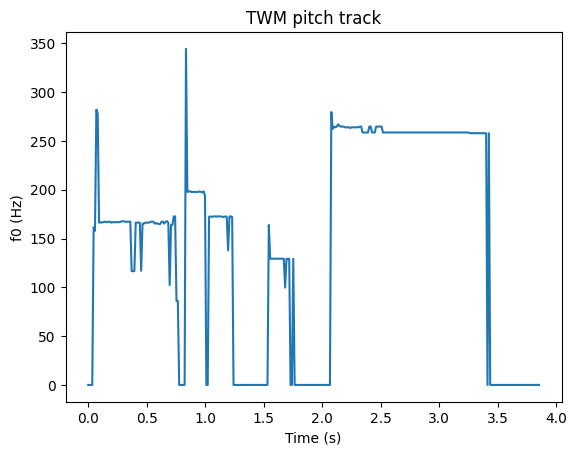

In [47]:
def octave_aware_smooth(contour, kernel_size=121):
    # Convert to log, median filter, convert back
    # prevent log(0) on silent frames
    log_contour = np.where(contour > 0, np.log2(contour), 0)
    smoothed_log = scipy.signal.medfilt(log_contour, kernel_size=kernel_size)
    return np.where(contour > 0, 2 ** smoothed_log, 0)

smoothed_pitch = octave_aware_smooth(pitch_contour, kernel_size=121)
times = t
plt.plot(times, pitch_contour)
plt.xlabel('Time (s)')
plt.ylabel('f0 (Hz)')
plt.title('TWM pitch track')
plt.show()

In [48]:
frame_times = t

total_samples = len(x)
sample_times = np.arange(total_samples) / sr

pitch_contour_interpolated = np.interp(sample_times, frame_times, pitch_contour)

phase = 2 * np.pi * np.cumsum(pitch_contour_interpolated) / sr

pitch_signal = np.sin(phase)
ipd.display(ipd.Audio(pitch_signal, rate=sr))

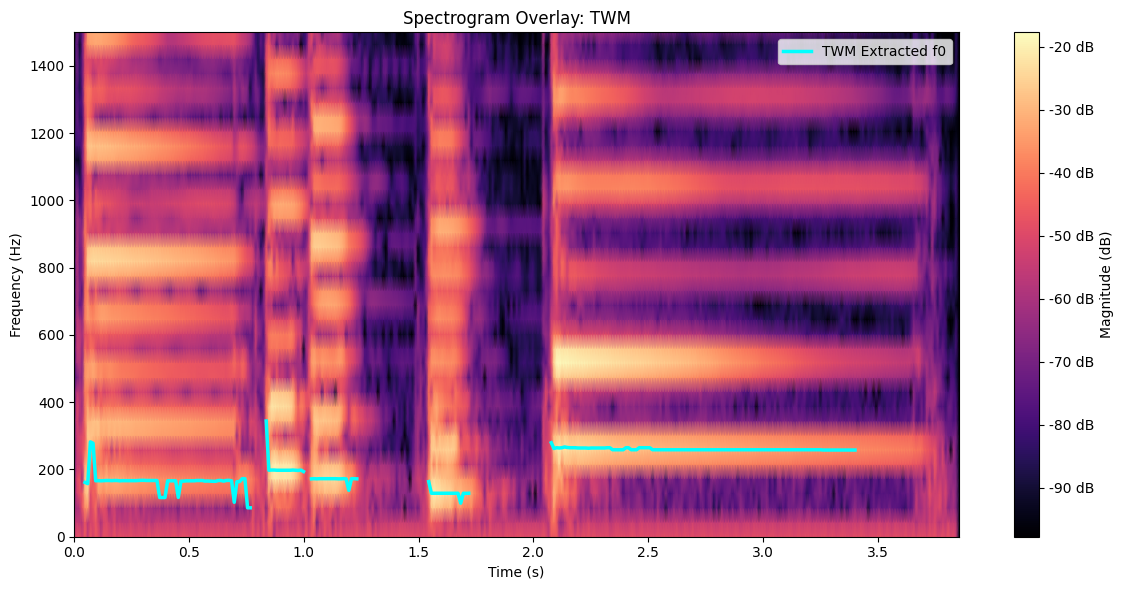

In [49]:
Zxx_dB = 20 * np.log10(np.maximum(Zxx_mag, 1e-10))

pitch_contour_plot = np.where(pitch_contour == 0, np.nan, pitch_contour)

plt.figure(figsize=(12, 6))

vmax = np.max(Zxx_dB)
plt.pcolormesh(t, f, Zxx_dB, shading='gouraud', cmap='magma', vmin=vmax - 80, vmax=vmax)
plt.colorbar(format='%+2.0f dB', label='Magnitude (dB)')

plt.plot(t, pitch_contour_plot, color='cyan', linewidth=2.5, label='TWM Extracted f0')


plt.ylim(0, 1500)
plt.xlim(t[0], t[-1])

plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram Overlay: TWM')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## what slightly improved the model
- changing signal.find_peaks() height => height + prominence
- masking the range($50<f_k < 4000$): somewhere improved somewhere got noisy
- increase kernel_size on scipy.signal.medfilt
- keep candidates that could explain the lowest strong peak
- at least 3 harmonics must fit below threshhold

## Previous YIN was significantly better
- TWM consistently drops out.
- The higher harmonics die off first which leaves mostly just the fundamental -> YIN tracks this well, but TWM requires multiple peaks to calculate, leading to no result.
- Struggled on the transition between notes

## Prospect
Time-Domain Algorithm are going to beat naive frequency-domain algo(TWM) for pure monophonic pitch tracking on real signal.

**Looking forward to TWM to shine on polyphonic analysis.**

Same setting on Flute, Oboe, Sax Phrase Short

flute

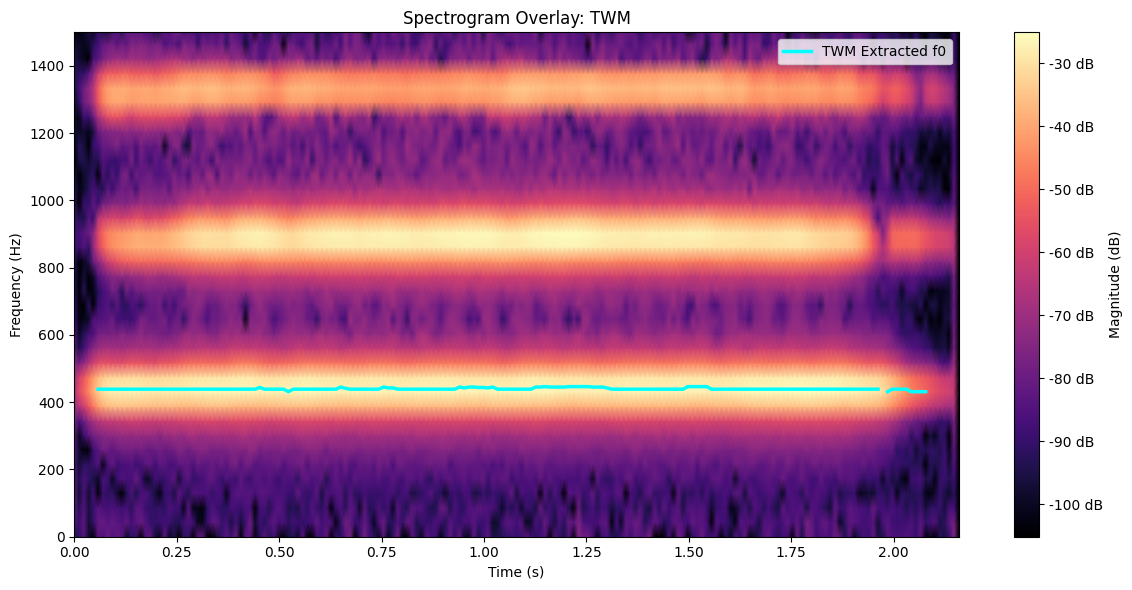

Oboe

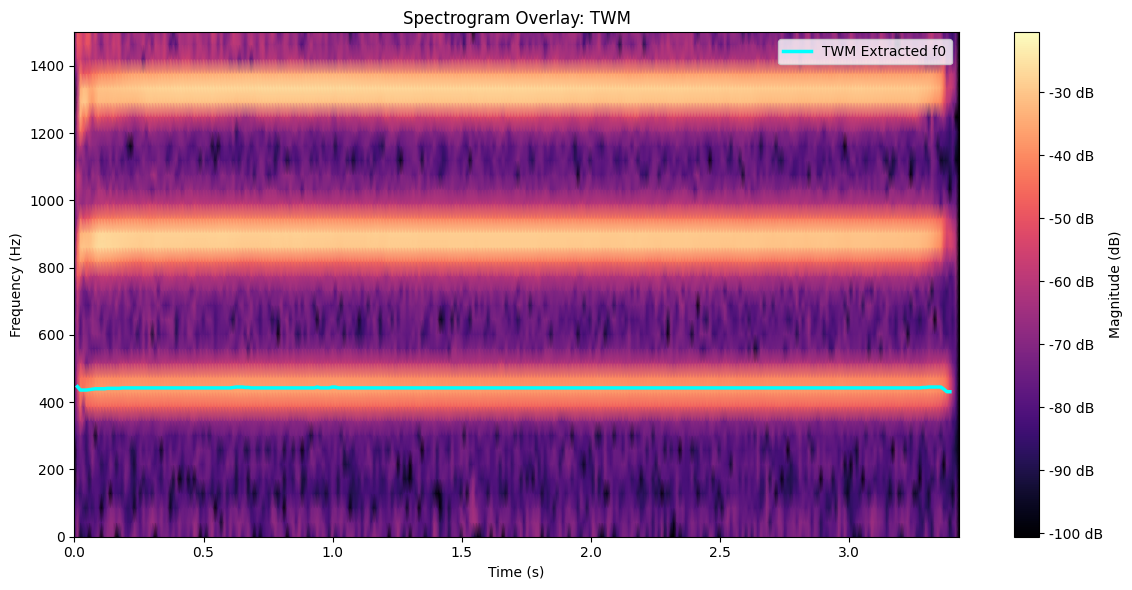

sax short phrase

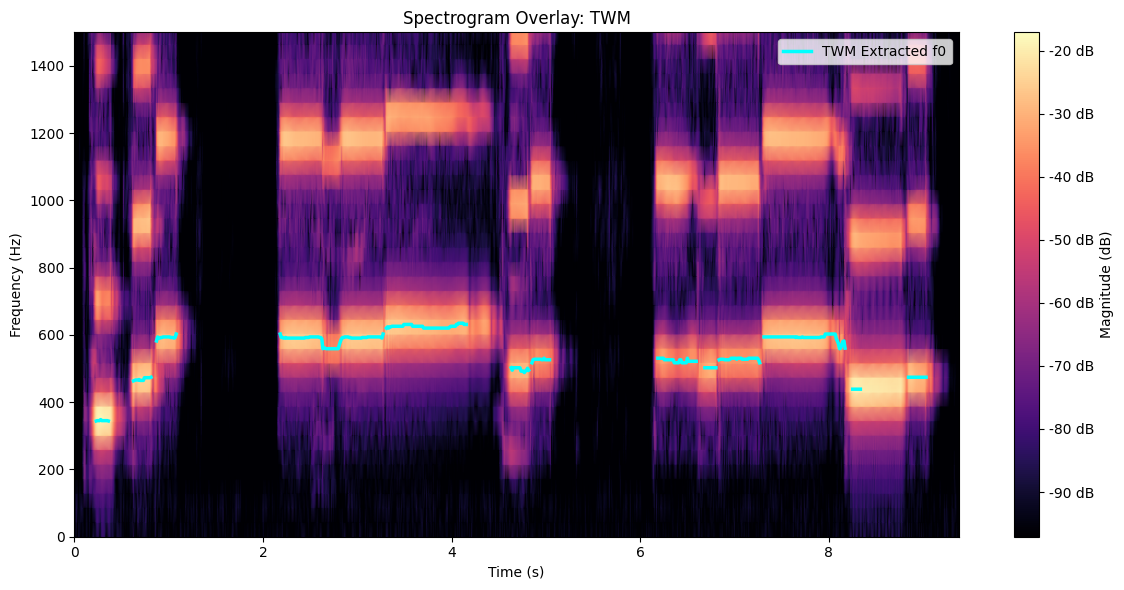